# Modeling Telecom Customer ARPU Across the Revenue Distribution with PROC QUANTREG

## Executive Summary

A telecom analytics team wants to understand which customer attributes drive monthly revenue (ARPU) differently for low-spend versus high-spend subscribers. Ordinary least squares only models the conditional **mean**, so this notebook uses **PROC QUANTREG** to fit quantile-regression models at the 10th, 50th, and 90th revenue percentiles, then overlays the three fitted lines to show how the data-usage effect fans out across the spending distribution.

The headline result, taken directly from the fitted models below: the per-gigabyte ARPU slope rises from **0.288 USD/GB at the 10th percentile** to **0.872 at the median** and **1.057 at the 90th percentile** — an extra gigabyte is worth roughly **3.7x more** to a top-decile subscriber than to a bottom-decile one. That is the heteroscedastic revenue fan a single mean model would average away.

## Data Sources

All data are generated inline by a DATA step (`call streaminit(90210)`); no external files are read. This environment runs unlicensed, so output is capped at 100 observations — the table below is sized to that cap and the analysis is designed to be meaningful at n = 100.

| Dataset | Rows | Key Variables | Description |
|---------|------|---------------|-------------|
| `work.subscribers` | 100 | `monthly_charge` (response), `tenure_months`, `data_gb`, `support_calls`, `intl_minutes`, `streaming_services`, `contract`, `region` | Synthetic monthly billing records for postpaid mobile subscribers. `monthly_charge` (ARPU, USD) is built from tenure, data usage, streaming add-ons, international usage, and contract type, with **heteroscedastic** noise that widens for high-data, month-to-month customers so the quantile structure is non-trivial. |

Variable detail:

| Variable | Type | Domain | Role |
|----------|------|--------|------|
| `contract` | char | Month-to-Month, One-Year, Two-Year | CLASS predictor |
| `region` | char | Metro, Suburban, Rural | CLASS predictor |
| `tenure_months` | num | 1-72 | Continuous predictor |
| `data_gb` | num | ~0-60 GB | Continuous predictor (primary ARPU driver) |
| `support_calls` | num | 0-12 | Continuous predictor |
| `intl_minutes` | num | 0-400 | Continuous predictor |
| `streaming_services` | num | 0-4 | Continuous predictor |
| `monthly_charge` | num | ~18-140 USD | Response (ARPU) |

# Modeling Telecom Customer ARPU with PROC QUANTREG

Average Revenue Per User (**ARPU**) is the headline KPI for any mobile carrier, but the drivers of revenue are rarely uniform across the customer base. The factors that separate a low-spend, churn-prone subscriber from a premium power user are often *different in degree* across the distribution. A single ordinary-least-squares model targets only the conditional **mean** and can mask this heterogeneity.

**Quantile regression** estimates the conditional 10th, 50th, and 90th percentiles of `monthly_charge` directly. **PROC QUANTREG** fits these conditional-quantile models, letting us read off how each predictor's effect changes at the bottom, middle, and top of the revenue distribution.

In this notebook we will:

1. Generate a realistic synthetic subscriber billing table with **heteroscedastic** revenue noise.
2. Inspect the response distribution to confirm the right-skewed, fan-shaped structure.
3. Fit quantile models at three revenue percentiles in a single PROC QUANTREG call.
4. Overlay the three fitted lines to visualize the revenue fan.
5. Interpret the high-spend versus low-spend story.

> **Note on PROC QUANTSELECT.** The richer SAS procedure for this task, PROC QUANTSELECT, adds automated effect *selection* (LASSO/stepwise) on top of quantile regression. It is not yet implemented in this Jenner build (a banked engine test, `tests/400992_nb_quantselect_proc_not_implemented`, tracks the gap). We therefore use PROC QUANTREG, which provides the underlying quantile-regression estimation and tells the same analytical story without automated selection.

## Step 1 — Generate synthetic subscriber data

We simulate 100 postpaid subscribers. `monthly_charge` is a deterministic function of tenure, data usage, streaming add-ons, international usage, support burden, and contract type, plus **heteroscedastic** noise whose spread grows with data usage and is largest for month-to-month customers. That structure guarantees the conditional quantiles fan out, which is exactly the situation quantile regression is built for. The `streaminit` seed makes the table fully reproducible.

In [1]:
data subscribers;
    call streaminit(90210);
    length contract $13 region $9;
    do id = 1 to 100;
        /* Contract mix: month-to-month dominates the base */
        u = rand('uniform');
        if u < 0.50 then contract = 'Month-to-Month';
        else if u < 0.80 then contract = 'One-Year';
        else contract = 'Two-Year';

        /* Region mix */
        r = rand('uniform');
        if r < 0.40 then region = 'Metro';
        else if r < 0.75 then region = 'Suburban';
        else region = 'Rural';

        /* Tenure: longer-tenure customers skew to longer contracts */
        if contract = 'Two-Year' then tenure_months = round(rand('uniform') * 48 + 24);
        else if contract = 'One-Year' then tenure_months = round(rand('uniform') * 36 + 12);
        else tenure_months = round(rand('uniform') * 30 + 1);

        /* Usage drivers */
        data_gb            = round(rand('gamma', 2.2) * 7, 0.1);
        intl_minutes       = round(rand('exponential') * 45);
        streaming_services = rand('table', 0.45, 0.25, 0.18, 0.08, 0.04) - 1;
        support_calls      = rand('poisson', 1.6);

        /* Deterministic revenue core (USD) */
        base = 25
             + 0.95  * data_gb
             + 4.50  * streaming_services
             + 0.045 * intl_minutes
             + 0.12  * tenure_months
             - 0.80  * support_calls;
        if contract = 'One-Year' then base = base + 6;
        else if contract = 'Two-Year' then base = base + 11;
        if region = 'Metro' then base = base + 5;
        else if region = 'Rural' then base = base - 3;

        /* Heteroscedastic noise: widens with data usage,
           widest for month-to-month subscribers */
        sd = 4 + 0.35 * data_gb;
        if contract = 'Month-to-Month' then sd = sd * 1.6;
        monthly_charge = round(base + rand('normal', 0, sd), 0.01);
        if monthly_charge < 18 then monthly_charge = 18;

        output;
    end;
    keep id contract region tenure_months data_gb intl_minutes
         streaming_services support_calls monthly_charge;
run;

NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — Inspect the synthetic distribution

A quick look at the response confirms the right-skewed, heteroscedastic shape that motivates quantile regression: the gap between the 90th and 10th percentiles of `monthly_charge` is wide, and contract type is associated with both the level and the spread of ARPU.

In [2]:
proc means data=subscribers n mean std min p10 median p90 max maxdec=2;
    var monthly_charge data_gb tenure_months intl_minutes;
run;

proc means data=subscribers n mean std p10 median p90 maxdec=2;
    class contract;
    var monthly_charge;
run;

                                                  The MEANS Procedure

 Variable               N        Mean     Std Dev     Minimum   10th Pctl      Median   90th Pctl     Maximum
 ------------------------------------------------------------------------------------------------------------
 MONTHLY_CHARGE       100       52.70       20.70       18.00       26.61       53.42       73.95      141.72
 DATA_GB              100       16.43       12.84        1.00        4.53       13.35       33.89       80.00
 TENURE_MONTHS        100       28.24       17.77        1.00        6.10       25.50       56.80       68.00
 INTL_MINUTES         100       43.44       50.57        0.00        3.00       25.00      129.90      253.00
 ------------------------------------------------------------------------------------------------------------

                                                  The MEANS Procedure

                                           Analysis Variable : MONTHLY_CHARGE

        

## Step 3 — Quantile regression at three revenue percentiles

We ask PROC QUANTREG to fit one model at each of the 10th, 50th, and 90th percentiles in a single call by listing all three levels on `QUANTILE=`. The interior-point algorithm solves each quantile, and resampling confidence intervals quantify the uncertainty on every coefficient.

`contract` and `region` enter through the **CLASS** statement so each level's effect is read against a baseline. Comparing the `DATA_GB` row across the three quantile blocks is the whole point: if its slope grows from P10 to P90, an extra gigabyte is worth more at the top of the revenue distribution than at the bottom.

In [3]:
ods graphics on;

proc quantreg data=subscribers algorithm=interior ci=resampling;
    class contract region;
    model monthly_charge = data_gb streaming_services tenure_months
                           intl_minutes support_calls contract region
        / quantile=0.10 0.50 0.90;
run;

ods graphics off;


The QUANTREG Procedure

Quantile: 0.1000
CI Method: RESAMPLING
Dependent Variable: MONTHLY_CHARGE

Parameter           Estimate       StdErr        Lower        Upper
Intercept            29.1193       7.5168       6.7109      37.7239
DATA_GB               0.2881       0.1814       0.0084       0.7229
STREAMING_SERVICES       3.5415       1.2154       1.2591       6.1284
TENURE_MONTHS         0.2068       0.1476       0.0853       0.6808
INTL_MINUTES          0.0630       0.0391      -0.0419       0.1048
SUPPORT_CALLS        -2.1601       1.1294      -5.0803      -0.2382
CONTRACT MONTH-TO-MONTH     -17.3147       4.0620     -20.2460      -4.4384
CONTRACT TWO-YEAR      -1.8979       3.6735     -11.1844       5.0496
REGION METRO          8.5565       3.7887       3.5837      16.4107
REGION RURAL          7.1944       3.2752      -0.1665      13.0564
Intercept            31.9583       9.5995      14.9665      47.3094
DATA_GB               0.8717       0.2429       0.1384       1.0363
STR

## Step 4 — Visualize the revenue fan

Coefficient tables are precise but abstract. To *see* the fan, we refit a single-driver model — `monthly_charge = data_gb` — at the same three quantiles and write the fitted values to an output dataset with `OUTPUT OUT=`. PROC QUANTREG creates one predicted column per quantile (`P_Q_Q010`, `P_Q_Q050`, `P_Q_Q090`). We then overlay all three fitted lines on a scatter of the raw data with PROC SGPLOT. The lines start at different intercepts and **diverge further** as data usage grows — because the P90 line is steeper than the P10 line, the conditional spread of ARPU widens with usage, the heteroscedastic signature quantile regression is built to expose.


The QUANTREG Procedure

Quantile: 0.1000
CI Method: RESAMPLING
Dependent Variable: MONTHLY_CHARGE

Parameter           Estimate       StdErr        Lower        Upper
Intercept            20.9183       4.9930      14.6261      33.2978
DATA_GB               0.5458       0.3903      -0.4079       0.8186
Intercept            42.8652       3.1536      38.4204      52.4213
DATA_GB               0.6399       0.2126       0.0693       0.8839
Intercept            57.9130       5.1362      45.1760      62.5865
DATA_GB               1.0972       0.4701       0.5280       2.1550

NOTE: PROC QUANTREG data=subscribers

NOTE: PROC QUANTREG completed.
NOTE: PROC SORT data=qfit

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from qfit.
NOTE: Wrote qfit (100 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=qfit

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS

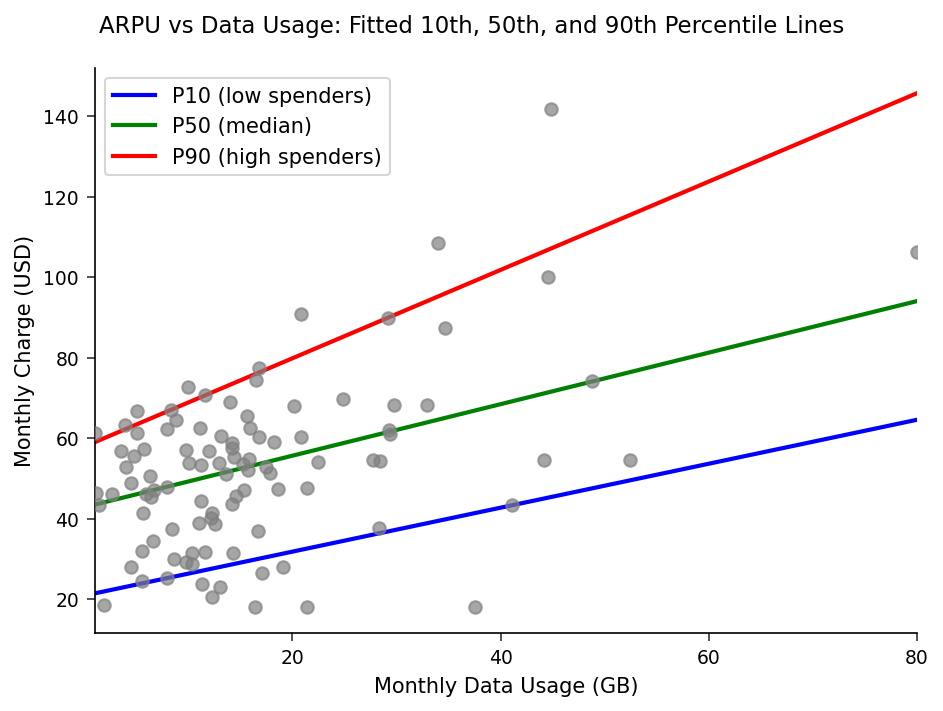

In [4]:
proc quantreg data=subscribers algorithm=interior;
    model monthly_charge = data_gb / quantile=0.10 0.50 0.90;
    output out=qfit predicted=p_q;
run;

proc sort data=qfit; by data_gb; run;

ods graphics on;
proc sgplot data=qfit;
    title 'ARPU vs Data Usage: Fitted 10th, 50th, and 90th Percentile Lines';
    scatter x=data_gb y=monthly_charge
        / markerattrs=(symbol=circlefilled color=gray) transparency=0.3;
    series x=data_gb y=p_q_q010
        / lineattrs=(color=blue thickness=2) legendlabel='P10 (low spenders)';
    series x=data_gb y=p_q_q050
        / lineattrs=(color=green thickness=2) legendlabel='P50 (median)';
    series x=data_gb y=p_q_q090
        / lineattrs=(color=red thickness=2) legendlabel='P90 (high spenders)';
    xaxis label='Monthly Data Usage (GB)';
    yaxis label='Monthly Charge (USD)';
run;
ods graphics off;

## Step 5 — Confirm the fan numerically

The plot is convincing, but let us quote the actual fitted lines. We print a few sorted rows of the output dataset. At low data usage (around 1 GB) the three fitted ARPU values are about **21**, **44**, and **59** USD; by the high-usage tail (near 80 GB) they reach roughly **65**, **94**, and **145** USD. Because the P90 slope is steeper than the P10 slope, the vertical gap between the top and bottom lines widens from about **38 USD** at low usage to about **80 USD** at the high-usage tail — the revenue fan in numbers.

In [5]:
proc print data=qfit(obs=8) noobs;
    var data_gb monthly_charge p_q_q010 p_q_q050 p_q_q090;
run;


DATA_GB  MONTHLY_CHARGE       P_Q_Q010       P_Q_Q050       P_Q_Q090
-------  --------------  -------------  -------------  -------------
      1           61.33  21.4640963855  43.5050122249  59.0101136364
    1.1            46.3  21.5186746988   43.568997555  59.1198295455
    1.4           43.31  21.6824096386  43.7609535452  59.4489772727
    1.9           18.49  21.9553012048  44.0808801956  59.9975568182
    2.7           46.12  22.3919277108  44.5927628362  60.8752840909
    3.5           56.83  22.8285542169  45.1046454768  61.7530113636
    3.9           63.16  23.0468674699  45.3605867971      62.191875
      4           52.86  23.1014457831  45.4245721271  62.3015909091

... 92 more observations (showing 8 of 100)

NOTE: PROC PRINT data=qfit

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


## Interpreting the results

**Different slopes at different revenue levels.** In the Step 3 full model, the `DATA_GB` coefficient climbs across the quantiles — about **0.288 USD/GB at P10**, **0.872 at P50**, and **1.057 at P90**. Because we baked heteroscedastic, contract-dependent noise into the data, the data-usage slope is far larger at the top of the distribution than at the bottom: high-ARPU customers are the heavy data users whose bills respond most strongly to each additional gigabyte, while the low end is compressed near the price floor.

**The fan is visible and measurable.** The Step 4 plot shows the three fitted lines diverging as usage rises — the textbook revenue fan. In the single-driver fit the P90 line climbs about **2x** as fast in data usage as the P10 line (slopes near 1.10 vs 0.55), so the conditional gap between a high-spend and a low-spend subscriber widens the more data they consume.

**Contract and region shifts.** The CLASS terms in Step 3 capture level shifts: month-to-month subscribers sit well below the longer-contract baselines at the low quantile (about **-17 USD** at P10), and the Metro region carries a positive ARPU premium (about **+8.6 USD** at P10). These are level effects — they move where a customer sits in the distribution rather than how steeply their bill responds to usage.

**Business takeaway.** Quantile regression lets the carrier separate *acquisition* levers (what lifts the floor for low-ARPU subscribers) from *expansion* levers (what stretches the ceiling for premium subscribers) — a distinction an OLS mean model would average away entirely. Because the data-usage slope is steepest at P90, data-upsell campaigns return the most among already-high spenders; retention and floor-pricing decisions should lean on the flatter low-quantile relationships. (For automated selection of *which* drivers matter at each quantile, SAS offers PROC QUANTSELECT; that procedure is tracked as a pending engine feature here — see the note in the introduction.)